# Practical: Comprehensive Study of Unsupervised Clustering
**Aim:** To implement and compare various clustering techniques—**K-Means**, **Hierarchical**, and **DBSCAN**—to group unlabeled data and evaluate their performance on different data geometries.

### **We will cover Mainly Three Methods of Clustering:**
1.  **K-Means:** Finds centers (Centroids). Best for round blobs.
2.  **Hierarchical:** Builds a tree (Dendrogram). Best for small datasets.
3.  **DBSCAN:** Finds crowded areas (Density). Best for weird shapes and removing noise.

Data Head:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


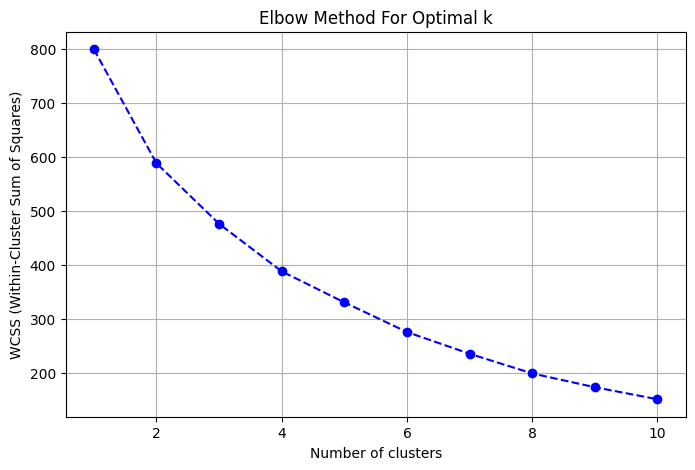


Data with Cluster Assignments:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        3  
1        3  
2        3  
3        3  
4        3  


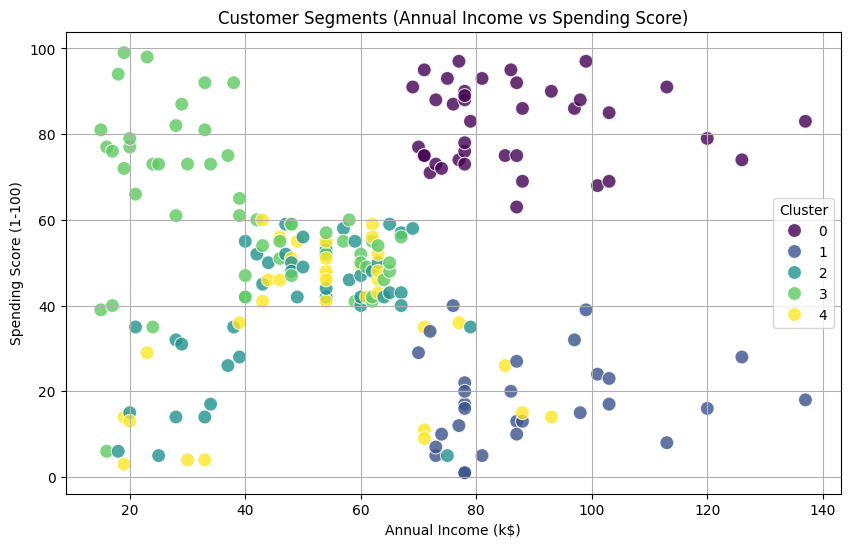

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the Data
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
df = pd.read_csv(url)

print("Data Head:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())

# 2. Data Preprocessing
# Drop CustomerID as it doesn't add value to clustering
X = df.drop('CustomerID', axis=1)

# Encode Gender (Male: 1, Female: 0)
X['Gender'] = X['Gender'].map({'Male': 1, 'Female': 0})

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Determine the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    # n_init=10 is used to suppress future warnings and run the algorithm 10 times with different centroid seeds
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

# 4. Apply K-Means Clustering
# (Based on standard analysis of this dataset, k=5 is usually the optimal elbow point)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster assignments back to the original dataframe
df['Cluster'] = clusters

print("\nData with Cluster Assignments:\n", df.head())

# 5. Visualizing the Clusters (Annual Income vs Spending Score)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.title('Customer Segments (Annual Income vs Spending Score)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


### What is WCSS?
**WCSS** stands for **Within-Cluster Sum of Squares**. In K-Means clustering, it is the primary metric used to measure how "tight" or compact your clusters are.

You can think of WCSS as a measurement of error. A lower WCSS means that the data points in a cluster are very close to the center of that cluster, meaning the group is highly similar.

### How is it Calculated?
To find the WCSS, the K-Means algorithm does the following:
1. **Finds the center (centroid):** It locates the exact center point of a specific cluster.
2. **Measures the distance:** It draws a line from that centroid to every single data point inside that cluster and measures the distance.
3. **Squares the distance:** It squares each of those distances (to heavily penalize points that are far away).
4. **Sums it up:** It adds all those squared distances together.
5. **Repeats:** It does this for every cluster and adds the final totals together to get the overall WCSS.



Mathematically, it looks like this:
$$WCSS=\sum_{i=1}^{k}\sum_{x\in C_i}(x-\mu_i)^2$$

**Where:**
* $k$ is the number of clusters.
* $C_i$ represents the $i^{th}$ cluster.
* $x$ represents a data point in that cluster.
* $\mu_i$ is the centroid (mean) of the $i^{th}$ cluster.

### Why do we use it in the Elbow Method?
When you increase the number of clusters ($k$), the WCSS will **always** go down. If you make a separate cluster for every single customer, the distance to the center is zero, so the WCSS would be exactly 0.

The **Elbow Method** plots the WCSS against the number of clusters.
* At first, as you add clusters, the WCSS drops drastically.
* Eventually, the line starts to flatten out.
* The "elbow" is the sweet spot: it is the point where adding more clusters doesn't significantly improve the compactness of the groups. That is your optimal number of clusters.

# Hierarchical Clustering

Hierarchical clustering is an alternative algorithm to K-Means. Instead of guessing the number of clusters ($k$) right away, it builds a "tree" of clusters (a hierarchy) that allows us to visualize the data's structure before deciding how many groups to create.

### Types of Hierarchical Clustering

There are two main approaches:

1. **Agglomerative (Bottom-Up):** This is the most common type. It starts by treating every single data point as its own individual cluster. Then, it finds the two closest clusters and merges them. It repeats this merging process step-by-step until all the data points are combined into one giant cluster.
   

2. **Divisive (Top-Down):** This is the exact opposite. It starts with all data points inside one massive cluster. Then, it splits the cluster into two, and continues splitting recursively until every single data point is its own separate cluster.
   

### The Dendrogram (Our Alternative to the Elbow Method)

In K-Means, we used the Elbow Method to find the optimal number of clusters. In Hierarchical Clustering, we use a **Dendrogram**.

A Dendrogram is a tree-like diagram that records every single merge (or split) the algorithm makes.
* The **x-axis** represents the individual data points.
* The **y-axis** represents the distance (or dissimilarity) between clusters.
* A horizontal line connecting two vertical lines means two clusters have been merged.



### Linkage Methods
When deciding which clusters to merge, the algorithm needs to know how to measure the distance between them. This is called **Linkage**. The most popular method is **Ward's Method**, which works by minimizing the variance (the spread) inside each cluster as they merge.

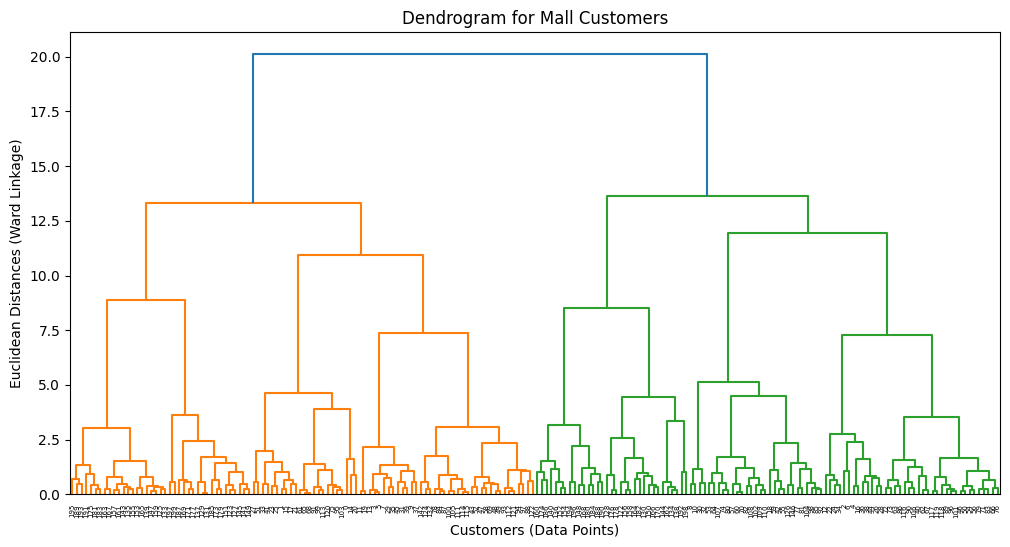


--- Data with Hierarchical Cluster Assignments ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  HC_Cluster  Divisive_Cluster  
0        3           0               2.0  
1        3           0               2.0  
2        3           3               1.0  
3        3           0               3.0  
4        3           3               3.0  


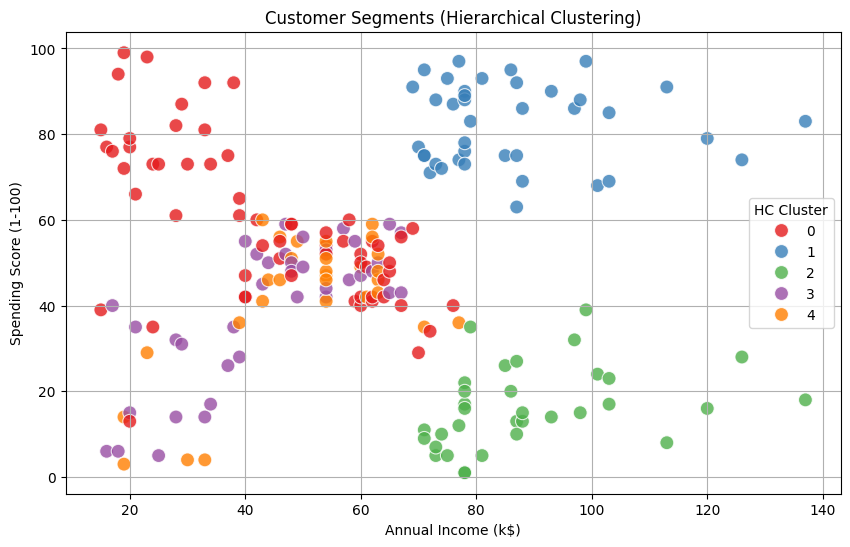

In [ ]:
# 3. FINDING OPTIMAL CLUSTERS USING A DENDROGRAM

# We use the scipy library to create the dendrogram
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'X_scaled' and 'df' from the previous data preprocessing step are still in memory

plt.figure(figsize=(12, 6))
plt.title('Dendrogram for Mall Customers')
plt.xlabel('Customers (Data Points)')
plt.ylabel('Euclidean Distances (Ward Linkage)')

# sch.linkage builds the hierarchy.
# We use 'ward' linkage to minimize variance within the clusters.
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))

# Display the dendrogram so we can visually find the longest vertical line
plt.grid(False)
plt.show()

# ==========================================
# 4. APPLYING AGGLOMERATIVE CLUSTERING
# ==========================================
from sklearn.cluster import AgglomerativeClustering

# Based on a typical dendrogram for this dataset, an imaginary horizontal line
# cutting the longest uncrossed vertical lines will intersect 5 vertical lines.
optimal_k_hc = 5

# Initialize the Agglomerative Clustering model
# metric='euclidean' calculates straight-line distance between points
hc = AgglomerativeClustering(n_clusters=optimal_k_hc, metric='euclidean', linkage='ward')

# Fit the model and predict the cluster labels for each customer
hc_clusters = hc.fit_predict(X_scaled)

# Add the new hierarchical cluster labels to our dataframe
df['HC_Cluster'] = hc_clusters

print("\n--- Data with Hierarchical Cluster Assignments ---")
print(df.head())

# 5. VISUALIZING THE HIERARCHICAL CLUSTERS
plt.figure(figsize=(10, 6))

# We plot the same Annual Income vs Spending Score, but colored by the new HC_Cluster
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='HC_Cluster',
    data=df,
    palette='Set1', # Using a different color palette to distinguish from K-Means
    s=100,
    alpha=0.8
)

plt.title('Customer Segments (Hierarchical Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='HC Cluster')
plt.grid(True)
plt.show()

### DBSCAN (Density-Based Spatial Clustering)

K-Means and Hierarchical clustering are great, but they have a major flaw: they force *every single data point* into a cluster, even if that point is an extreme outlier. They also struggle with clusters that aren't perfectly round.

**DBSCAN** solves this. Instead of calculating distance from a center point, it looks at the **density** of the data. It groups together points that are tightly packed and marks points that are sitting out in the middle of nowhere as **Noise (Outliers)**.



#### How DBSCAN Works (The 3 Types of Points)
DBSCAN requires two parameters to define "density":
1. **`eps` (Epsilon):** The maximum radius of a circle drawn around a data point.
2. **`min_samples`:** The minimum number of data points that must fall inside that circle for it to be considered a dense region.

Based on these parameters, DBSCAN classifies every point into one of three categories:
* **Core Point:** A point that has at least `min_samples` within its `eps` radius. (It is in the thick of a cluster).
* **Border Point:** A point that has fewer than `min_samples` within its radius, but it is sitting right on the edge of a Core Point's circle. (It is part of the cluster, but on the outside boundary).
* **Noise (Outlier):** A point that is neither a Core nor a Border point. It is ignored and not assigned to any cluster.

#### How do we find the optimal `eps`? (The k-Distance Graph)
Just like K-Means uses the Elbow Method, DBSCAN uses a **k-Distance Graph**.
We calculate the distance from every point to its $k^{th}$ nearest neighbor (where $k$ is our `min_samples`). We sort these distances and plot them. The point where the graph bends sharply (the "elbow" or "knee") gives us our optimal `eps` value.

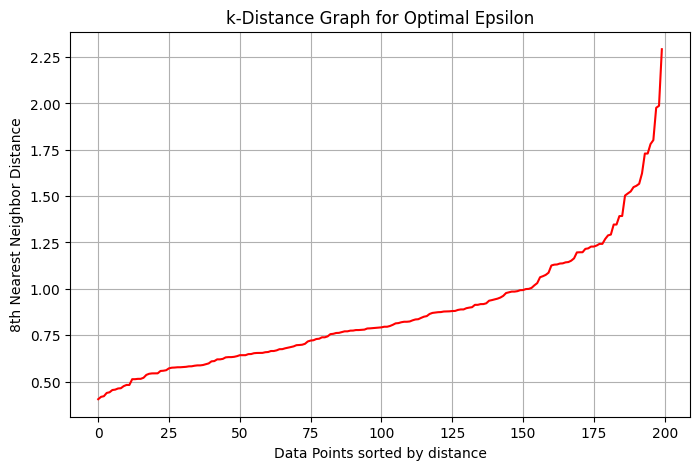


--- Data with DBSCAN Cluster Assignments ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  HC_Cluster  Divisive_Cluster  DBSCAN_Cluster  
0        3           0               2.0               0  
1        3           0               2.0               0  
2        3           3               1.0              -1  
3        3           0               3.0               1  
4        3           3               3.0               1  


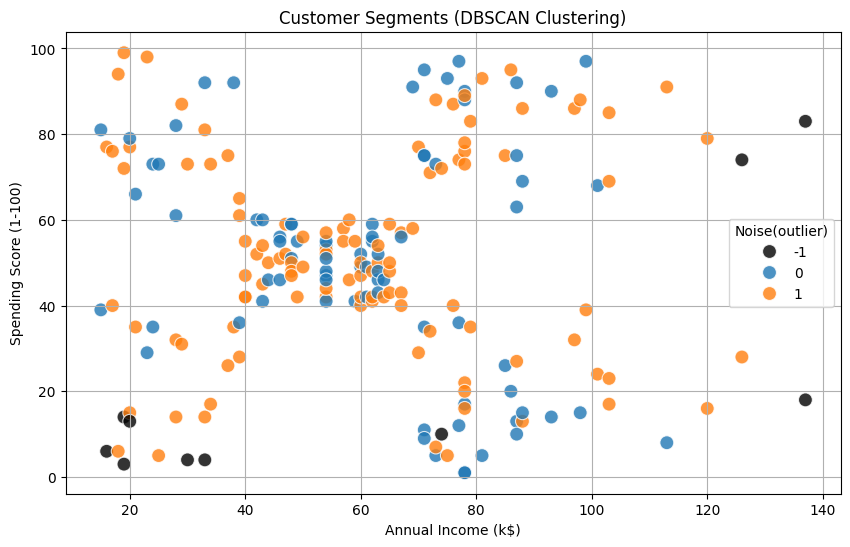

In [ ]:

# 1. FINDING OPTIMAL EPSILON (k-Distance Graph)

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Rule of thumb for min_samples: >= 2 * number of dimensions (features).
# We have 4 features (Gender, Age, Income, Spending), so we'll use 8.
min_samples = 8

# We calculate the distance to the 8th nearest neighbor for every data point
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort the distances from smallest to largest
distances = np.sort(distances[:, min_samples-1], axis=0)

# Plot the k-Distance Graph
plt.figure(figsize=(8, 5))
plt.plot(distances, color='red')
plt.title('k-Distance Graph for Optimal Epsilon')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

# If you look at the graph, the line sharply bends upward around the 1.0 to 1.2 mark.
# This "knee" is our optimal eps value. Let's use 1.1.


# 2. APPLYING DBSCAN CLUSTERING

optimal_eps = 1.1

# Initialize and fit the DBSCAN model
dbscan = DBSCAN(eps=optimal_eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Add the DBSCAN labels to our dataframe
df['DBSCAN_Cluster'] = dbscan_labels

print("\n--- Data with DBSCAN Cluster Assignments ---")
print(df.head())
# Note: Any customer with a cluster label of '-1' is considered NOISE (an outlier)



# 3. VISUALIZING THE DBSCAN CLUSTERS

plt.figure(figsize=(10, 6))

# We will create a custom color palette to ensure Noise points (-1) are colored Black
unique_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
palette = sns.color_palette("tab10", unique_clusters)

# Map the colors: cluster numbers get normal colors, -1 gets black
color_dict = {label: palette[i] for i, label in enumerate(set(dbscan_labels) - {-1})}
color_dict[-1] = (0, 0, 0) # Black for noise

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='DBSCAN_Cluster',
    data=df,
    palette=color_dict,
    s=100,
    alpha=0.8
)

plt.title('Customer Segments (DBSCAN Clustering)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Noise(outlier)')
plt.grid(True)
plt.show()